<a href="https://colab.research.google.com/github/PhongGHub/PhongGHub/blob/main/Test2_Pizza.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**การนำเข้าไลบรารี** (**Imports**)**bold text**

In [1]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
from torchvision import datasets
import torchvision.models as models
from torch.utils.data import DataLoader
from tqdm import tqdm
import matplotlib.pyplot as plt
from PIL import Image
import torch.nn.functional as F

**ส่วนของฟังก์ชันหลักสำหรับการเทรนโมเดล (main)**

In [2]:
def main():
    data_dir = r'D:\OneDrive - National Institute of Development Administration\2568(Term2)\DeepLearning\Mid-Term (Pizza)\Test_ResNet'
    batch_size = 18
    num_epochs = 3
    num_classes = 4
    model_save_path = 'pizza_classifier_resnet18.pth'
    test_image_path = 'test_pizza.jpg'

    device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")

    normalize = transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])

    train_transforms = transforms.Compose([
        transforms.RandomResizedCrop(224),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        normalize
    ])

    val_transforms = transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        normalize
    ])

    try:
        train_dataset = datasets.ImageFolder(os.path.join(data_dir, 'train'), train_transforms)
        val_dataset = datasets.ImageFolder(os.path.join(data_dir, 'val'), val_transforms)

        train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
        val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
        class_names = train_dataset.classes
    except FileNotFoundError:
        print(f"Error: Dataset not found at {data_dir}. Please check the path.")
        return

    resnet18_model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

    for param in resnet18_model.parameters():
        param.requires_grad = True

    num_features = resnet18_model.fc.in_features
    resnet18_model.fc = nn.Linear(num_features, num_classes)
    resnet18_model = resnet18_model.to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(resnet18_model.parameters(), lr=0.001)

    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

    for epoch in range(num_epochs):
        print(f'\nEpoch {epoch+1}/{num_epochs}')
        print('-' * 10)

        for phase in ['train', 'val']:
            if phase == 'train':
                resnet18_model.train()
                dataloader = train_loader
            else:
                resnet18_model.eval()
                dataloader = val_loader

            running_loss = 0.0
            running_corrects = 0

            progress_bar = tqdm(dataloader, desc=f'{phase.capitalize()}', leave=False)

            for inputs, labels in progress_bar:
                inputs = inputs.to(device)
                labels = labels.to(device)

                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    outputs = resnet18_model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

                progress_bar.set_postfix(loss=loss.item())

            epoch_loss = running_loss / len(dataloader.dataset)
            epoch_acc = (running_corrects.double() / len(dataloader.dataset)).item()

            print(f'{phase.capitalize()} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

            history[f'{phase}_loss'].append(epoch_loss)
            history[f'{phase}_acc'].append(epoch_acc)

    print("\n--- Training Complete ---")

    epochs_range = range(1, num_epochs + 1)
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, history['train_loss'], label='Train Loss', marker='o')
    plt.plot(epochs_range, history['val_loss'], label='Validation Loss', marker='o')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, history['train_acc'], label='Train Accuracy', marker='o')
    plt.plot(epochs_range, history['val_acc'], label='Validation Accuracy', marker='o')
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.savefig('training_history.png')
    plt.show()

    torch.save(resnet18_model.state_dict(), model_save_path)
    print(f"Model saved to {model_save_path}")

    try:
        image = Image.open(test_image_path).convert('RGB')
        input_tensor = val_transforms(image)
        input_batch = input_tensor.unsqueeze(0).to(device)

        resnet18_model.eval()
        with torch.no_grad():
            output = resnet18_model(input_batch)

        probabilities = F.softmax(output[0], dim=0)
        max_prob, predicted_idx = torch.max(probabilities, 0)
        predicted_class = class_names[predicted_idx.item()]

        print(f"\nPrediction for {test_image_path}:")
        print(f"Class: {predicted_class}")
        print(f"Confidence: {max_prob.item() * 100:.2f}%")

        plt.figure(figsize=(6, 6))
        plt.imshow(image)
        plt.title(f"File: {test_image_path}\nPrediction: {predicted_class} ({max_prob.item() * 100:.2f}%)")
        plt.axis('off')
        plt.show()

    except FileNotFoundError:
        print(f"\nTest image not found at {test_image_path}. Skipping inference.")

**ส่วนของฟังก์ชันเรียกใช้โมเดลเดิมมาทำนาย (predict_only)**

In [3]:
def predict_only(image_path, model_path='pizza_classifier_resnet18.pth'):
    device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
    class_names = ['Hawaiian', 'Margherita', 'Pepperoni', 'Seafood']

    resnet18_model = models.resnet18(weights=None)
    resnet18_model.fc = nn.Linear(resnet18_model.fc.in_features, 4)
    resnet18_model.load_state_dict(torch.load(model_path, map_location=device))
    resnet18_model = resnet18_model.to(device)
    resnet18_model.eval()

    val_transforms = transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

    try:
        image = Image.open(image_path).convert('RGB')
        input_tensor = val_transforms(image).unsqueeze(0).to(device)
        with torch.no_grad():
            output = resnet18_model(input_tensor)
        probabilities = F.softmax(output[0], dim=0)
        max_prob, predicted_idx = torch.max(probabilities, 0)
        print(f"\n[ทำนายจากโมเดลเดิม] Prediction for {image_path}:")
        print(f"Class: {class_names[predicted_idx.item()]}")
        print(f"Confidence: {max_prob.item() * 100:.2f}%")

        plt.figure(figsize=(6, 6))
        plt.imshow(image)
        plt.title(f"File: {image_path}\nPrediction: {class_names[predicted_idx.item()]} ({max_prob.item() * 100:.2f}%)")
        plt.axis('off')
        plt.show()

    except FileNotFoundError:
        print(f"ไม่พบไฟล์รูปภาพ: {image_path}")

**ส่วนควบคุมโปรแกรมและแสดงเมนูรับคำสั่ง**

Please input Target File Name: test_pizza(s).jpg

--- เมนู ---
1 = เริ่มเทรนโมเดลใหม่อีกครั้งก่อนทำนาย
2 = ใช้โมเดลเดิมทำนาย โดยไม่ต้องเทรนใหม่
3 = ออกจากโปรแกรม
เลือกเมนู (1/2/3): 2

[ทำนายจากโมเดลเดิม] Prediction for test_pizza(s).jpg:
Class: Seafood
Confidence: 99.91%


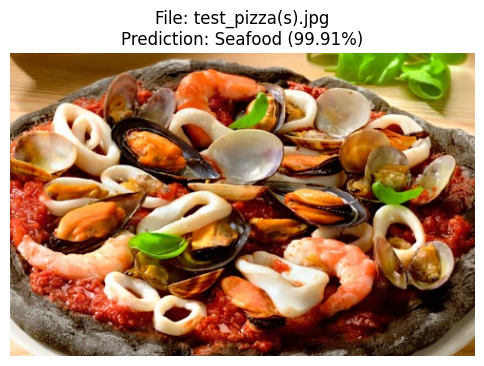

In [12]:
# ไม่ต้องใช้ if __name__ == '__main__': ใน Jupyter ก็ได้ครับ สามารถวางโค้ดลอยๆ แบบนี้ได้เลย
model_file = 'pizza_classifier_resnet18.pth'

target_image = input('Please input Target File Name: ')

print("\n--- เมนู ---")
print("1 = เริ่มเทรนโมเดลใหม่อีกครั้งก่อนทำนาย")
print("2 = ใช้โมเดลเดิมทำนาย โดยไม่ต้องเทรนใหม่")
print("3 = ออกจากโปรแกรม")

choice = input("เลือกเมนู (1/2/3): ")

if choice == '1':
    main()
elif choice == '2':
    if os.path.exists(model_file):
        predict_only(target_image, model_file)
    else:
        print("ไม่พบไฟล์โมเดล")